In [ ]:
import os
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from scipy.signal import medfilt
import scipy.ndimage
from scipy.ndimage import median_filter
import random
import matplotlib.pyplot as plt
import csv

# Normal Median Filtered Histogram 

In [ ]:
def f0_to_midi(frequency):
    return 69 + 12 * np.log2(frequency / 440)

def extract_pitch_changes (midi_notes, threshold = 0.5):
    midi_notes = np.round(midi_notes)
    changes = np.insert(np.diff(midi_notes), 0, 0)
    significant_changes = np.where(abs(changes) >= threshold)[0]
    return midi_notes[significant_changes]

def compute_intervals(midi_notes):
    return np.diff(midi_notes)

def aggregate_pitch_by_window(midi_notes, window_size = 20, method = "median"):
    aggregated = []
    for i in range(0, len(midi_notes), window_size):
        window = midi_notes[i: i + window_size]
        if len(window) == 0:
            continue
        if method == "mean":
            aggregated.append(np.mean(window))
        else:
            aggregated.append(np.median(window))
    return np.array(aggregated)

def process_f0_file(file_path):
    df = pd.read_csv(file_path, header = None)

    df.columns = ['Time', 'F0']

    df["F0"] = pd.to_numeric(df["F0"], errors = 'coerce')

    f0_values = df["F0"].values

    valid_f0_values = f0_values[~np.isnan(f0_values)]

    midi_notes = f0_to_midi(valid_f0_values)

    midi_notes = aggregate_pitch_by_window(midi_notes, window_size = 25, method = "median")

    lower_bound = 41
    upper_bound = 72

    stable_midi_notes = [x for x in midi_notes if lower_bound <= x < upper_bound]

    return stable_midi_notes

def get_interval_histogram(intervals_list, bin_size = 1):
    edges = np.arange(-12, 12 + bin_size, bin_size)
    hist, _ = np.histogram(intervals_list, bins = edges, density = True)
    return hist, edges

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

def frequency_to_midi(frequency):
    return 69 + 12 * np.log2(np.nan_to_num(frequency) / 440)

def get_midi_contour_from_csv(csv_fn, low_pitch=41, high_pitch=77):
    try:
        df = pd.read_csv(csv_fn)
        df.columns = ["time", "frequency", "confidence"]

        frequency = df['frequency'].values
        confidence = df['confidence'].values
        threshold = 0.7
        frequency[confidence < threshold] = np.nan

        filtered_frequency = median_filter(frequency, size=5, mode='nearest')

        pitch_in_midi = [frequency_to_midi(freq) for freq in filtered_frequency]
        midi_notes = [x for x in pitch_in_midi if low_pitch <= x < high_pitch]

        return midi_notes
    except Exception as e:
        print(f"Error processing {csv_fn}: {e}")
        return []

def get_histogram(midi_notes, bin_size=0.25):
    edges = np.arange(41, 77 + bin_size, bin_size)
    hist, _ = np.histogram(midi_notes, bins=edges, density=True)
    return hist, edges

file_path = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0'
output_path = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/Histogram/FullVocal'
os.makedirs(output_path, exist_ok=True)

for file_name in os.listdir(file_path):
    if file_name.endswith(".csv"):
        f0_path = os.path.join(file_path, file_name)
        midi_notes = get_midi_contour_from_csv(f0_path)

        if midi_notes:
            histogram, edges = get_histogram(midi_notes)
            bin_centers = (edges[:-1] + edges[1:]) / 2

            plt.figure(figsize=(10, 6))
            plt.bar(bin_centers, histogram, width = 1, align='center', alpha= 1)
            plt.xticks(edges[::4], labels=[f"{e:.2f}" for e in edges[::4]], rotation=45)
            plt.xlabel("Interval (Semitones)")
            plt.ylabel("Probability Density")
            plt.title(f"Pitch Histogram - {file_name}")
            plt.grid(axis="y", linestyle="--", alpha=0.7)

            save_path = os.path.join(output_path, f"{os.path.splitext(file_name)[0]}.png")
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            plt.close()

            print(f"Saved: {save_path}")

/tmp/ipykernel_173831/1551401091.py:8: RuntimeWarning: divide by zero encountered in log2
  return 69 + 12 * np.log2(np.nan_to_num(frequency) / 440)
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 48317 (\N{HANGUL SYLLABLE BYEOG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  

Saved: /home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/Histogram/FullVocal/06 적벽가 중 장승타령에서부터 관운장 나오는데까지3_GMjo.png


/tmp/ipykernel_173831/1551401091.py:8: RuntimeWarning: divide by zero encountered in log2
  return 69 + 12 * np.log2(np.nan_to_num(frequency) / 440)
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 48317 (\N{HANGUL SYLLABLE BYEOG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  

Saved: /home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/Histogram/FullVocal/06 적벽가 중 장승타령에서부터 관운장 나오는데까지5_Ujo.png


/tmp/ipykernel_173831/1551401091.py:8: RuntimeWarning: divide by zero encountered in log2
  return 69 + 12 * np.log2(np.nan_to_num(frequency) / 440)
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 48393 (\N{HANGUL SYLLABLE BONG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 52632 (\N{HANGUL SYLLABLE CUN}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
  p

...

/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 52632 (\N{HANGUL SYLLABLE CUN}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 54413 (\N{HANGUL SYLLABLE PUNG}) missing 

Saved: /home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/Histogram/FullVocal/화초가(정춘풍제), 심청가_Ujo.png


/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 48393 (\N{HANGUL SYLLABLE BONG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 52632 (\N{HANGUL SYLLABLE CUN}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing

Saved: /home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/Histogram/FullVocal/박봉술 춘향가 천자뒤풀이 김명환_3_Ujo.png
Saved: /home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/Histogram/FullVocal/수궁가 중 소지노화(신만엽제)_Ujo.png


/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 44417 (\N{HANGUL SYLLABLE GUNG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_173831/1551401091.py:57: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing fro

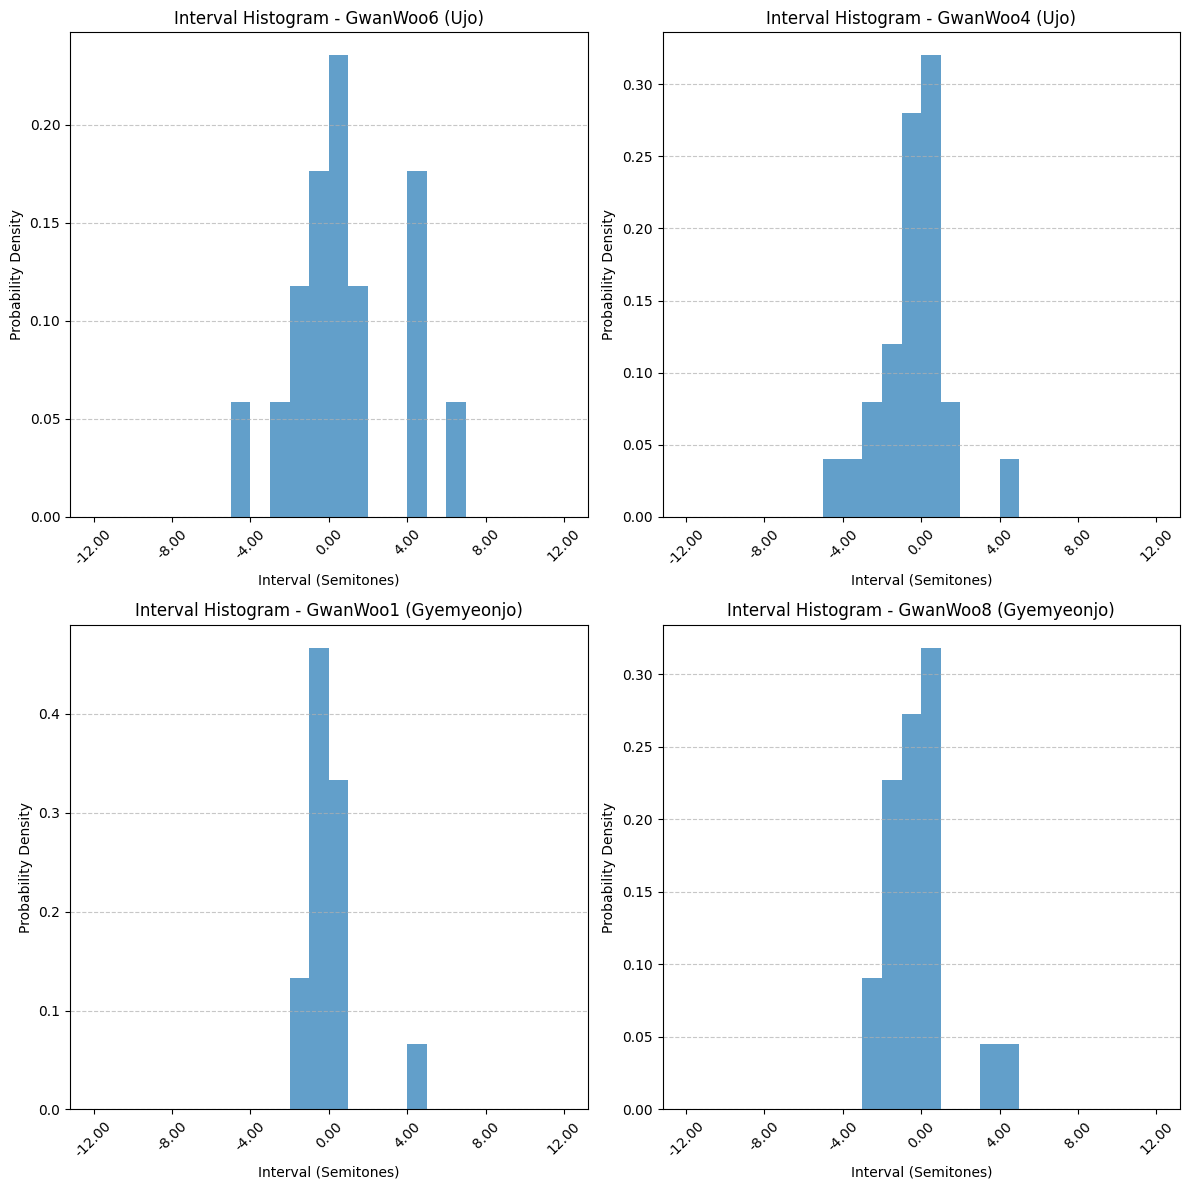

Ujo vs Ujo Bhattacharyya Distance: 0.0903
Ujo vs Gyemyeon Bhattacharyya Distance: 0.1436
Gyemyeon vs Gyemyeon Bhattacharyya Distance: 0.0926
Ujo vs Gyemyeon Bhattacharyya Distance: 0.1182


In [ ]:
file_paths = [
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Median_Filtered/적벽가 장승타령 관운장 6(우조)_clip_10-20.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Median_Filtered/적벽가 장승타령 관운장4(우조)_clip_10-20.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Median_Filtered/적벽가 장승타령 관운장1(계면)_clip_120-130.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Median_Filtered/적벽가 장승타령 관운장 3(계면)_clip_30-40.csv'
]

histograms = []
bin_edges = 0.5

for file_path in file_paths:
    midi_notes = process_f0_file(file_path)
    intervals_list = compute_intervals(midi_notes)
    hist, edges = get_interval_histogram(intervals_list)
    histograms.append(hist)
    bin_edges = edges

bin_centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(12, 12))

titles = [
    "Interval Histogram - GwanWoo6 (Ujo)",
    "Interval Histogram - GwanWoo4 (Ujo)",
    "Interval Histogram - GwanWoo1 (Gyemyeonjo)",
    "Interval Histogram - GwanWoo8 (Gyemyeonjo)"
]

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.bar(bin_centers, histograms[i], width=1, align='center', alpha=0.7)
    plt.xticks(bin_edges[::4], labels=[f"{e:.2f}" for e in bin_edges[::4]], rotation=45)
    plt.xlabel("Interval (Semitones)")
    plt.ylabel("Probability Density")
    plt.title(titles[i])
    plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

bhattacharyya_coeff = np.sum(np.sqrt(histograms[0] * histograms[1]))
bhattacharyya_distance = -np.log(bhattacharyya_coeff)
print(f"Ujo vs Ujo Bhattacharyya Distance: {bhattacharyya_distance:.4f}")

bhattacharyya_coeff2 = np.sum(np.sqrt(histograms[1] * histograms[2]))
bhattacharyya_distance2 = -np.log(bhattacharyya_coeff2)
print(f"Ujo vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance2:.4f}")

bhattacharyya_coeff3 = np.sum(np.sqrt(histograms[2] * histograms[3]))
bhattacharyya_distance3 = -np.log(bhattacharyya_coeff3)
print(f"Gyemyeon vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance3:.4f}")

bhattacharyya_coeff4 = np.sum(np.sqrt(histograms[1] * histograms[3]))
bhattacharyya_distance4 = -np.log(bhattacharyya_coeff4)
print(f"Ujo vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance4:.4f}")

## 20 sec audio

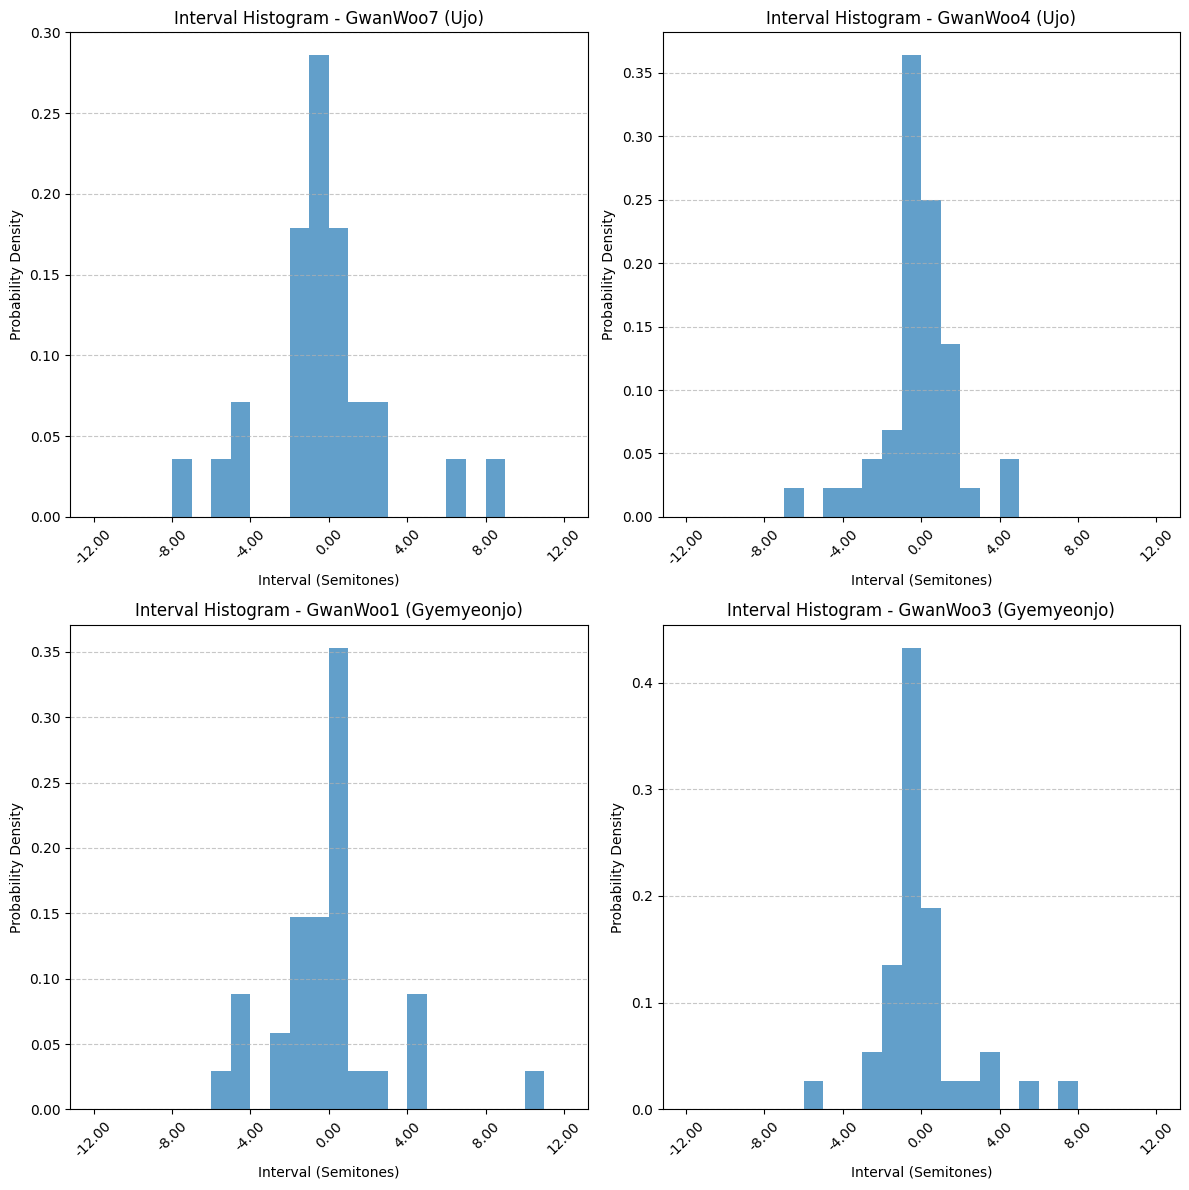

Ujo vs Ujo Bhattacharyya Distance: 0.1945
Ujo vs Gyemyeon Bhattacharyya Distance: 0.1308
Gyemyeon vs Gyemyeon Bhattacharyya Distance: 0.2325
Ujo vs Gyemyeon Bhattacharyya Distance: 0.1683


In [ ]:
file_paths = [
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Median_Filtered_20/적벽가 장승타령 관운장7(우조)_clip_60-80.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Median_Filtered_20/적벽가 장승타령 관운장4(우조)_clip_0-20.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Median_Filtered_20/적벽가 장승타령 관운장1(계면)_clip_100-120.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Median_Filtered_20/적벽가 장승타령 관운장 3(계면)_clip_80-100.csv'
]

histograms = []
bin_edges = 0.5

for file_path in file_paths:
    midi_notes = process_f0_file(file_path)
    intervals_list = compute_intervals(midi_notes)
    hist, edges = get_interval_histogram(intervals_list)
    histograms.append(hist)
    bin_edges = edges

bin_centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(12, 12))

titles = [
    "Interval Histogram - GwanWoo7 (Ujo)",
    "Interval Histogram - GwanWoo4 (Ujo)",
    "Interval Histogram - GwanWoo1 (Gyemyeonjo)",
    "Interval Histogram - GwanWoo3 (Gyemyeonjo)"
]

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.bar(bin_centers, histograms[i], width=1, align='center', alpha=0.7)
    plt.xticks(bin_edges[::4], labels=[f"{e:.2f}" for e in bin_edges[::4]], rotation=45)
    plt.xlabel("Interval (Semitones)")
    plt.ylabel("Probability Density")
    plt.title(titles[i])
    plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

bhattacharyya_coeff = np.sum(np.sqrt(histograms[0] * histograms[1]))
bhattacharyya_distance = -np.log(bhattacharyya_coeff)
print(f"Ujo vs Ujo Bhattacharyya Distance: {bhattacharyya_distance:.4f}")

bhattacharyya_coeff2 = np.sum(np.sqrt(histograms[1] * histograms[2]))
bhattacharyya_distance2 = -np.log(bhattacharyya_coeff2)
print(f"Ujo vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance2:.4f}")

bhattacharyya_coeff3 = np.sum(np.sqrt(histograms[2] * histograms[3]))
bhattacharyya_distance3 = -np.log(bhattacharyya_coeff3)
print(f"Gyemyeon vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance3:.4f}")

bhattacharyya_coeff4 = np.sum(np.sqrt(histograms[1] * histograms[3]))
bhattacharyya_distance4 = -np.log(bhattacharyya_coeff4)
print(f"Ujo vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance4:.4f}")

## SVM Classifier

# Morphological Histogram

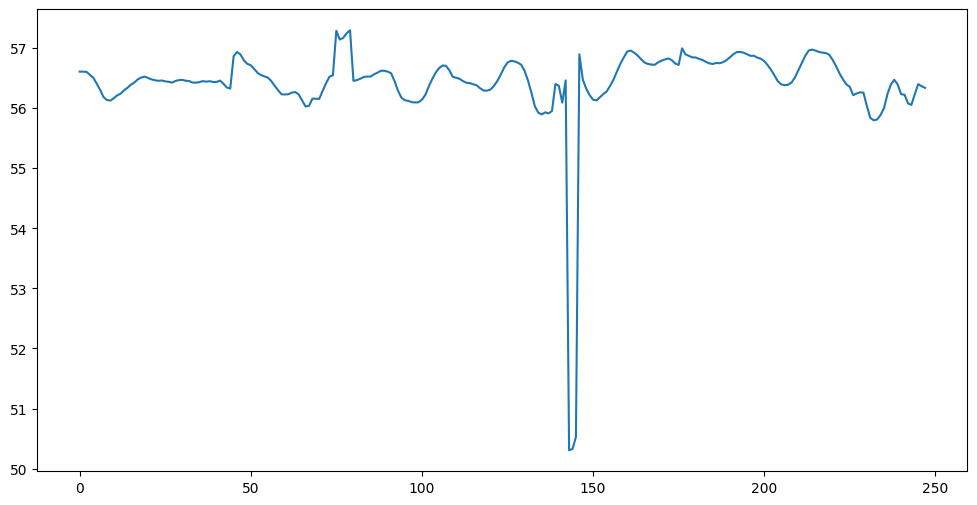

In [ ]:
def f0_to_midi(frequency):
    return 69 + 12 * np.log2(frequency / 440)

file_path =  '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/morph_filtered.csv'
df = pd.read_csv(file_path, header = None)

df.columns = ['F0', 'Time']
f0_values = df["F0"].values
valid_f0_values = f0_values[~np.isnan(f0_values)]
midi_notes = f0_to_midi(valid_f0_values)

lower_bound = 41
upper_bound = 72

midi_notes = [x for x in midi_notes if lower_bound <= x < upper_bound]

plt.figure(figsize=(12, 6))
plt.plot(midi_notes)
plt.show()

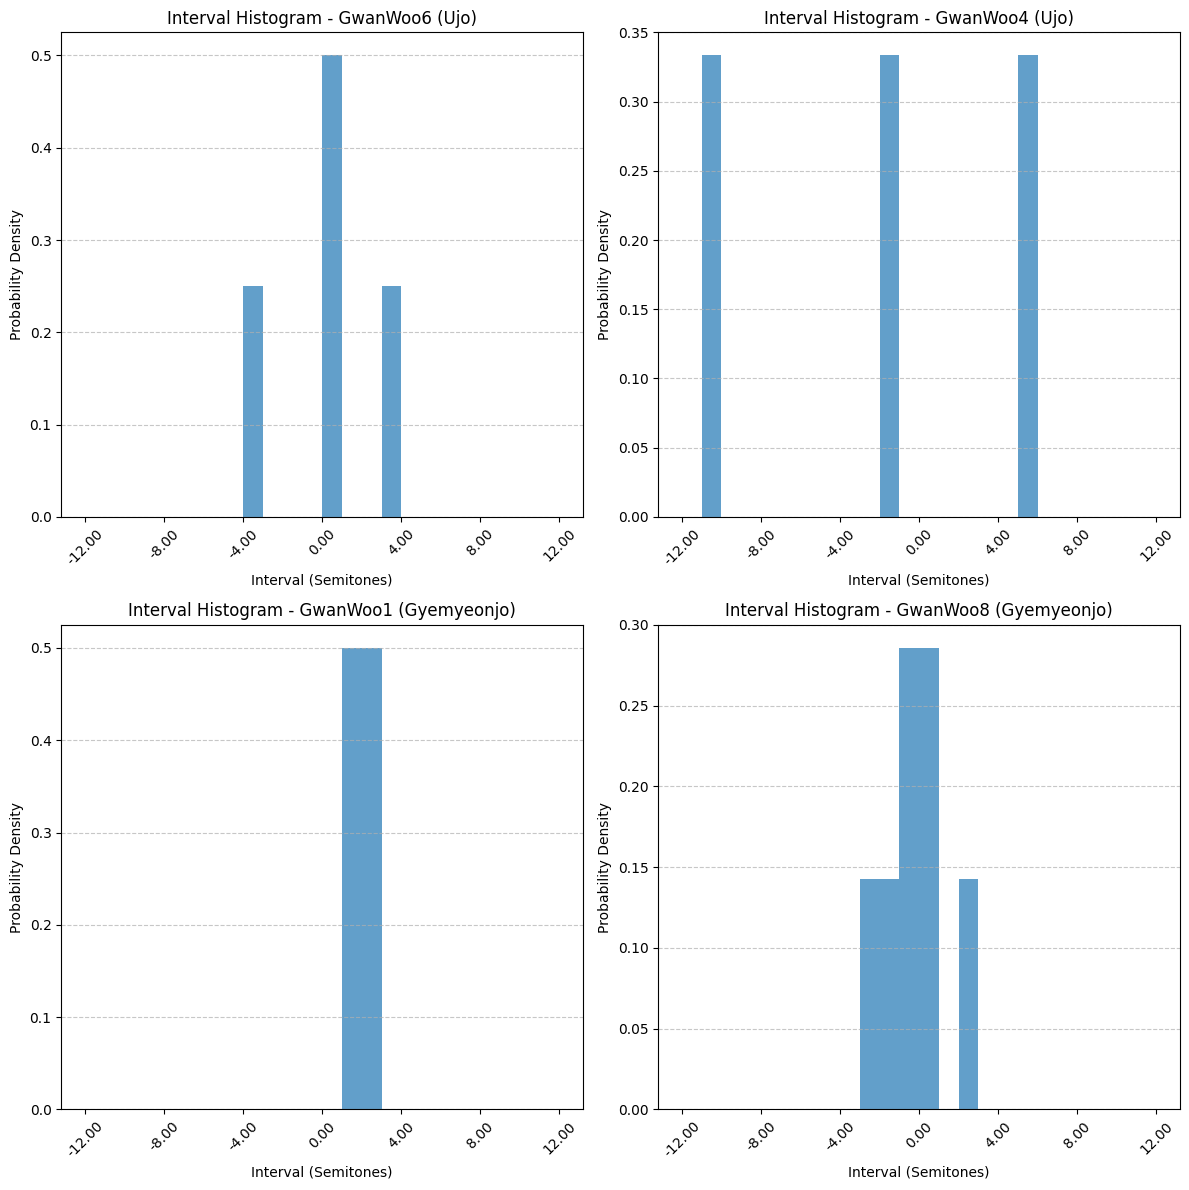

Ujo vs Ujo Bhattacharyya Distance: inf
Ujo vs Gyemyeon Bhattacharyya Distance: inf
Gyemyeon vs Gyemyeon Bhattacharyya Distance: 1.3195
Ujo vs Gyemyeon Bhattacharyya Distance: 1.5223


/tmp/ipykernel_159042/1039057408.py:42: RuntimeWarning: divide by zero encountered in log
  bhattacharyya_distance = -np.log(bhattacharyya_coeff)
/tmp/ipykernel_159042/1039057408.py:46: RuntimeWarning: divide by zero encountered in log
  bhattacharyya_distance2 = -np.log(bhattacharyya_coeff2)


In [ ]:
file_paths = [
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Morph_Filtered/적벽가 장승타령 관운장 6(우조)_clip_10-20.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Morph_Filtered/적벽가 장승타령 관운장4(우조)_clip_10-20.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Morph_Filtered/적벽가 장승타령 관운장1(계면)_clip_120-130.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Morph_Filtered/적벽가 장승타령 관운장 3(계면)_clip_30-40.csv'
]

histograms = []
bin_edges = 0.5

for file_path in file_paths:
    midi_notes = process_f0_file(file_path)
    intervals_list = compute_intervals(midi_notes)
    hist, edges = get_interval_histogram(intervals_list)
    histograms.append(hist)
    bin_edges = edges

bin_centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(12, 12))

titles = [
    "Interval Histogram - GwanWoo6 (Ujo)",
    "Interval Histogram - GwanWoo4 (Ujo)",
    "Interval Histogram - GwanWoo1 (Gyemyeonjo)",
    "Interval Histogram - GwanWoo8 (Gyemyeonjo)"
]

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.bar(bin_centers, histograms[i], width=1, align='center', alpha=0.7)
    plt.xticks(bin_edges[::4], labels=[f"{e:.2f}" for e in bin_edges[::4]], rotation=45)
    plt.xlabel("Interval (Semitones)")
    plt.ylabel("Probability Density")
    plt.title(titles[i])
    plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

bhattacharyya_coeff = np.sum(np.sqrt(histograms[0] * histograms[1]))
bhattacharyya_distance = -np.log(bhattacharyya_coeff)
print(f"Ujo vs Ujo Bhattacharyya Distance: {bhattacharyya_distance:.4f}")

bhattacharyya_coeff2 = np.sum(np.sqrt(histograms[1] * histograms[2]))
bhattacharyya_distance2 = -np.log(bhattacharyya_coeff2)
print(f"Ujo vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance2:.4f}")

bhattacharyya_coeff3 = np.sum(np.sqrt(histograms[2] * histograms[3]))
bhattacharyya_distance3 = -np.log(bhattacharyya_coeff3)
print(f"Gyemyeon vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance3:.4f}")

bhattacharyya_coeff4 = np.sum(np.sqrt(histograms[1] * histograms[3]))
bhattacharyya_distance4 = -np.log(bhattacharyya_coeff4)
print(f"Ujo vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance4:.4f}")

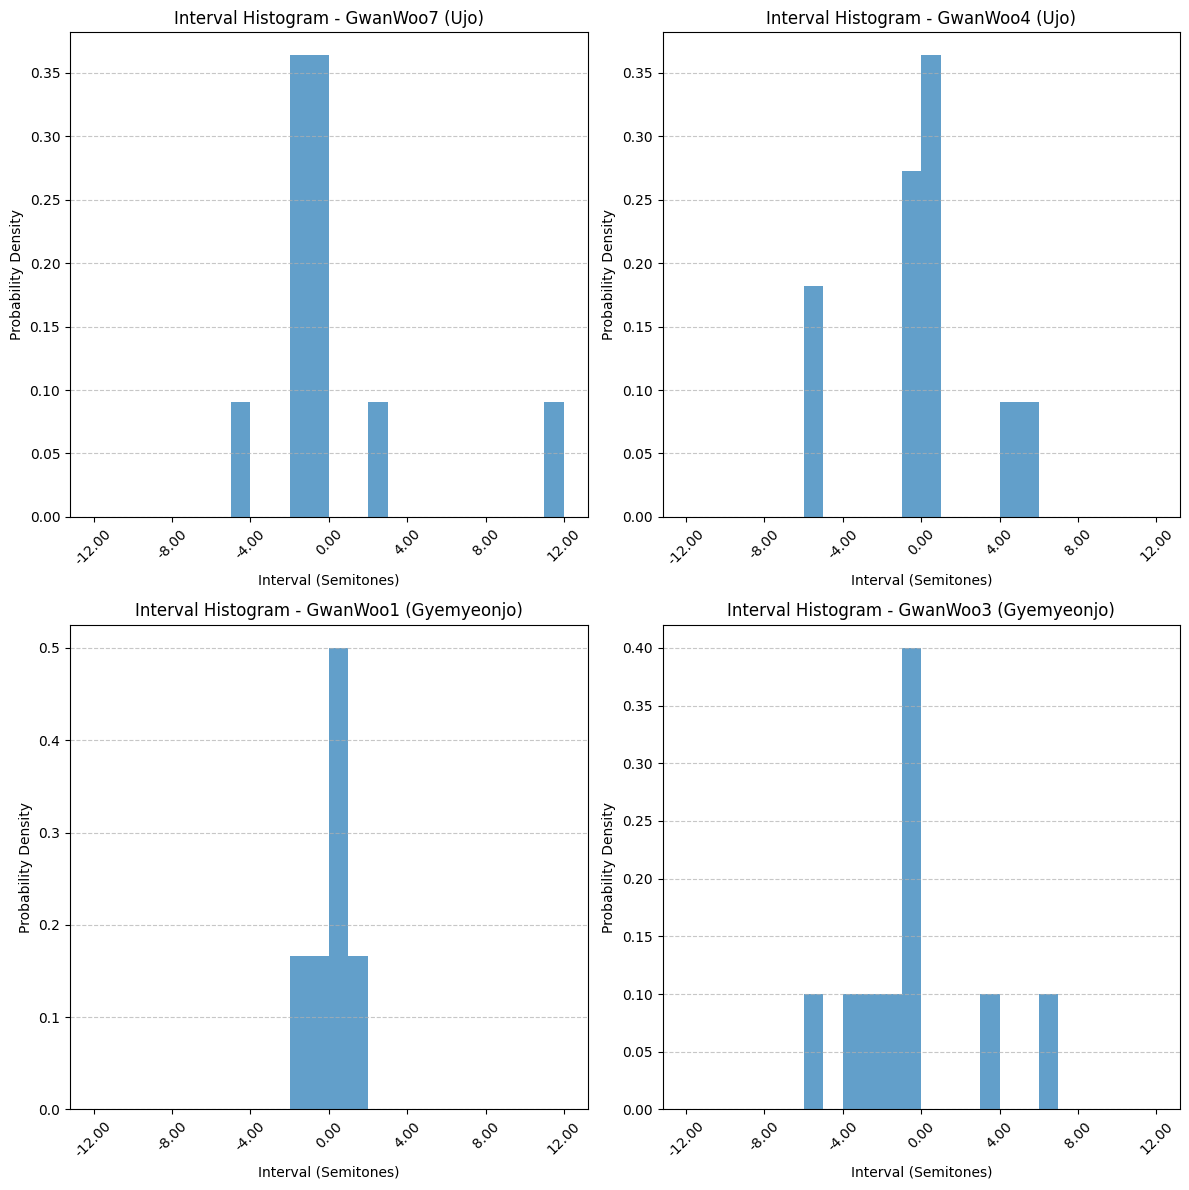

Ujo vs Ujo Bhattacharyya Distance: 1.1554
Ujo vs Gyemyeon Bhattacharyya Distance: 0.4469
Gyemyeon vs Gyemyeon Bhattacharyya Distance: 0.9486
Ujo vs Gyemyeon Bhattacharyya Distance: 0.7654


In [ ]:
file_paths = [
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Morph_Filtered_20/적벽가 장승타령 관운장7(우조)_clip_60-80.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Morph_Filtered_20/적벽가 장승타령 관운장4(우조)_clip_0-20.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Morph_Filtered_20/적벽가 장승타령 관운장1(계면)_clip_100-120.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Morph_Filtered_20/적벽가 장승타령 관운장 3(계면)_clip_80-100.csv'
]

histograms = []
bin_edges = 0.5

for file_path in file_paths:
    midi_notes = process_f0_file(file_path)
    intervals_list = compute_intervals(midi_notes)
    hist, edges = get_interval_histogram(intervals_list)
    histograms.append(hist)
    bin_edges = edges

bin_centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(12, 12))

titles = [
    "Interval Histogram - GwanWoo7 (Ujo)",
    "Interval Histogram - GwanWoo4 (Ujo)",
    "Interval Histogram - GwanWoo1 (Gyemyeonjo)",
    "Interval Histogram - GwanWoo3 (Gyemyeonjo)"
]

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.bar(bin_centers, histograms[i], width=1, align='center', alpha=0.7)
    plt.xticks(bin_edges[::4], labels=[f"{e:.2f}" for e in bin_edges[::4]], rotation=45)
    plt.xlabel("Interval (Semitones)")
    plt.ylabel("Probability Density")
    plt.title(titles[i])
    plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

bhattacharyya_coeff = np.sum(np.sqrt(histograms[0] * histograms[1]))
bhattacharyya_distance = -np.log(bhattacharyya_coeff)
print(f"Ujo vs Ujo Bhattacharyya Distance: {bhattacharyya_distance:.4f}")

bhattacharyya_coeff2 = np.sum(np.sqrt(histograms[1] * histograms[2]))
bhattacharyya_distance2 = -np.log(bhattacharyya_coeff2)
print(f"Ujo vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance2:.4f}")

bhattacharyya_coeff3 = np.sum(np.sqrt(histograms[2] * histograms[3]))
bhattacharyya_distance3 = -np.log(bhattacharyya_coeff3)
print(f"Gyemyeon vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance3:.4f}")

bhattacharyya_coeff4 = np.sum(np.sqrt(histograms[1] * histograms[3]))
bhattacharyya_distance4 = -np.log(bhattacharyya_coeff4)
print(f"Ujo vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance4:.4f}")

# Mask Filtered Histogram

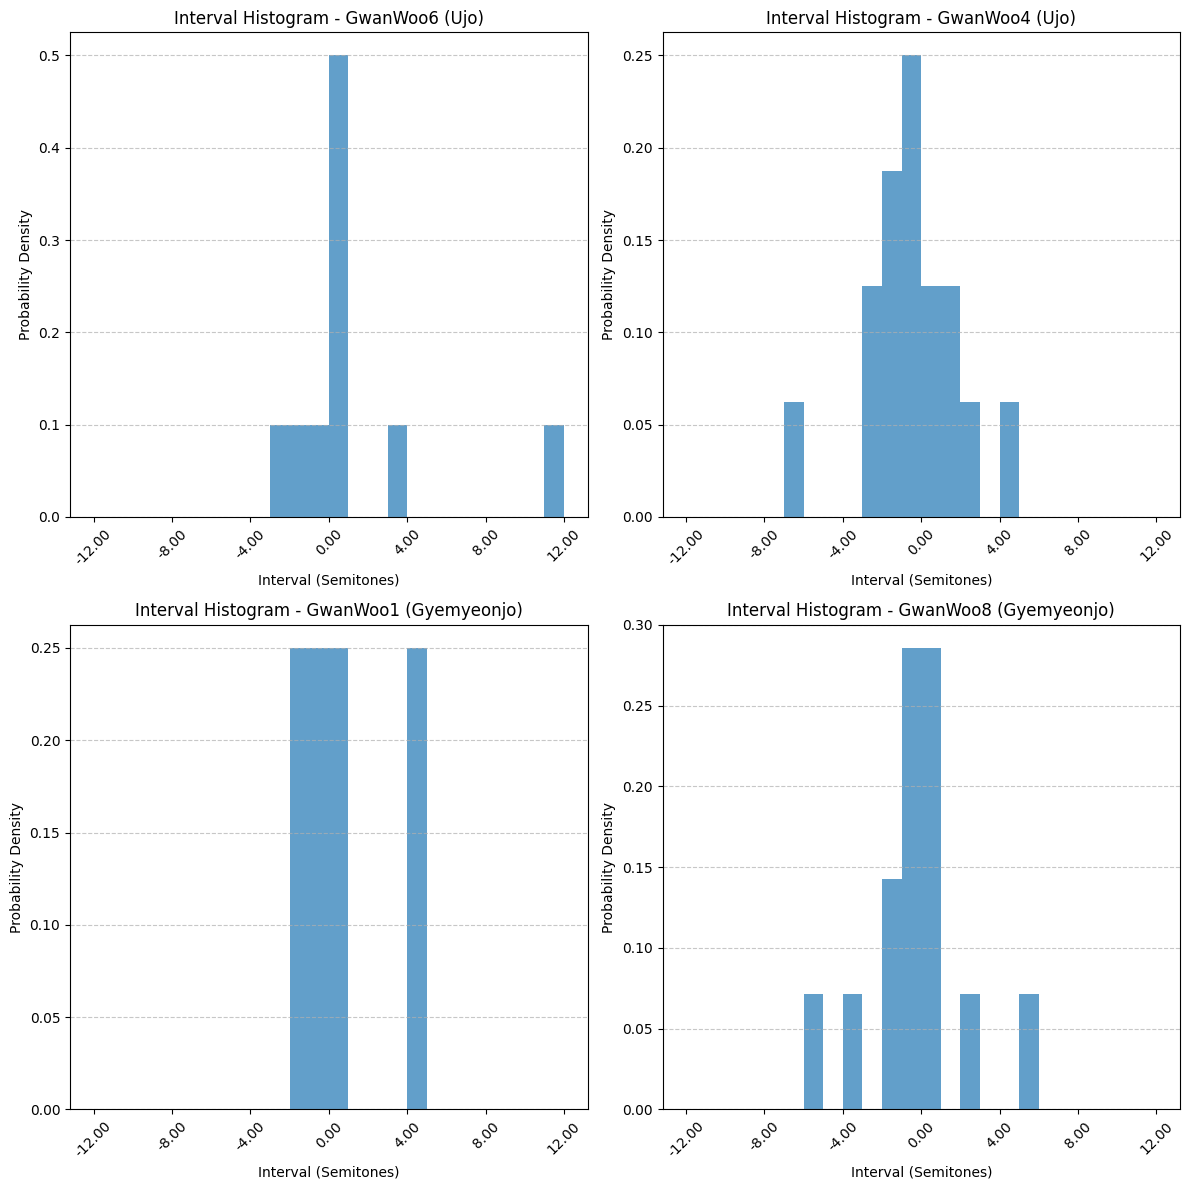

Ujo vs Ujo Bhattacharyya Distance: 0.4203
Ujo vs Gyemyeon Bhattacharyya Distance: 0.2636
Gyemyeon vs Gyemyeon Bhattacharyya Distance: 0.3236
Ujo vs Gyemyeon Bhattacharyya Distance: 0.3758


In [ ]:
file_paths = [
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Mask_Filtered/적벽가 장승타령 관운장 6(우조)_clip_10-20.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Mask_Filtered/적벽가 장승타령 관운장4(우조)_clip_10-20.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Mask_Filtered/적벽가 장승타령 관운장1(계면)_clip_120-130.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Mask_Filtered/적벽가 장승타령 관운장 3(계면)_clip_30-40.csv',
]

histograms = []
bin_edges = 0.5

for file_path in file_paths:
    midi_notes = process_f0_file(file_path)
    intervals_list = compute_intervals(midi_notes)
    hist, edges = get_interval_histogram(intervals_list)
    histograms.append(hist)
    bin_edges = edges

bin_centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(12, 12))

titles = [
    "Interval Histogram - GwanWoo6 (Ujo)",
    "Interval Histogram - GwanWoo4 (Ujo)",
    "Interval Histogram - GwanWoo1 (Gyemyeonjo)",
    "Interval Histogram - GwanWoo8 (Gyemyeonjo)"
]

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.bar(bin_centers, histograms[i], width=1, align='center', alpha=0.7)
    plt.xticks(bin_edges[::4], labels=[f"{e:.2f}" for e in bin_edges[::4]], rotation=45)
    plt.xlabel("Interval (Semitones)")
    plt.ylabel("Probability Density")
    plt.title(titles[i])
    plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

bhattacharyya_coeff = np.sum(np.sqrt(histograms[0] * histograms[1]))
bhattacharyya_distance = -np.log(bhattacharyya_coeff)
print(f"Ujo vs Ujo Bhattacharyya Distance: {bhattacharyya_distance:.4f}")

bhattacharyya_coeff2 = np.sum(np.sqrt(histograms[1] * histograms[2]))
bhattacharyya_distance2 = -np.log(bhattacharyya_coeff2)
print(f"Ujo vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance2:.4f}")

bhattacharyya_coeff3 = np.sum(np.sqrt(histograms[2] * histograms[3]))
bhattacharyya_distance3 = -np.log(bhattacharyya_coeff3)
print(f"Gyemyeon vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance3:.4f}")

bhattacharyya_coeff4 = np.sum(np.sqrt(histograms[1] * histograms[3]))
bhattacharyya_distance4 = -np.log(bhattacharyya_coeff4)
print(f"Ujo vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance4:.4f}")

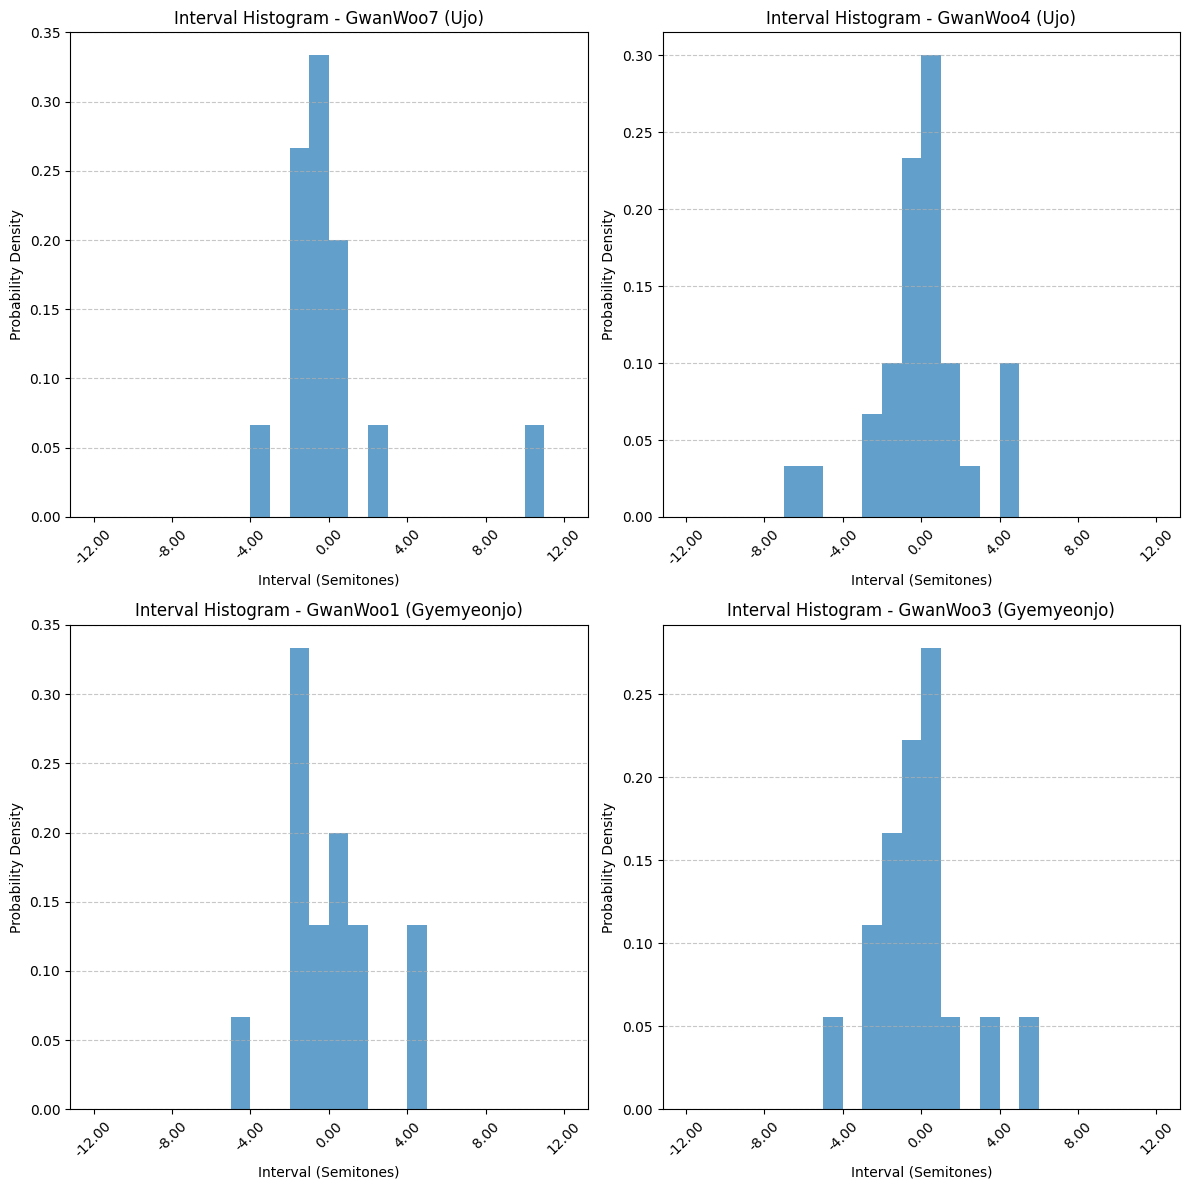

Ujo vs Ujo Bhattacharyya Distance: 0.3089
Ujo vs Gyemyeon Bhattacharyya Distance: 0.1805
Gyemyeon vs Gyemyeon Bhattacharyya Distance: 0.2351
Ujo vs Gyemyeon Bhattacharyya Distance: 0.2156


In [ ]:
file_paths = [
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Mask_Filtered_20/적벽가 장승타령 관운장7(우조)_clip_60-80.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Mask_Filtered_20/적벽가 장승타령 관운장4(우조)_clip_0-20.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Mask_Filtered_20/적벽가 장승타령 관운장1(계면)_clip_100-120.csv',
    '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0_Mask_Filtered_20/적벽가 장승타령 관운장 3(계면)_clip_80-100.csv'
]

histograms = []
bin_edges = 0.5

for file_path in file_paths:
    midi_notes = process_f0_file(file_path)
    intervals_list = compute_intervals(midi_notes)
    hist, edges = get_interval_histogram(intervals_list)
    histograms.append(hist)
    bin_edges = edges

bin_centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(12, 12))

titles = [
    "Interval Histogram - GwanWoo7 (Ujo)",
    "Interval Histogram - GwanWoo4 (Ujo)",
    "Interval Histogram - GwanWoo1 (Gyemyeonjo)",
    "Interval Histogram - GwanWoo3 (Gyemyeonjo)"
]

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.bar(bin_centers, histograms[i], width=1, align='center', alpha=0.7)
    plt.xticks(bin_edges[::4], labels=[f"{e:.2f}" for e in bin_edges[::4]], rotation=45)
    plt.xlabel("Interval (Semitones)")
    plt.ylabel("Probability Density")
    plt.title(titles[i])
    plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

bhattacharyya_coeff = np.sum(np.sqrt(histograms[0] * histograms[1]))
bhattacharyya_distance = -np.log(bhattacharyya_coeff)
print(f"Ujo vs Ujo Bhattacharyya Distance: {bhattacharyya_distance:.4f}")

bhattacharyya_coeff2 = np.sum(np.sqrt(histograms[1] * histograms[2]))
bhattacharyya_distance2 = -np.log(bhattacharyya_coeff2)
print(f"Ujo vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance2:.4f}")

bhattacharyya_coeff3 = np.sum(np.sqrt(histograms[2] * histograms[3]))
bhattacharyya_distance3 = -np.log(bhattacharyya_coeff3)
print(f"Gyemyeon vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance3:.4f}")

bhattacharyya_coeff4 = np.sum(np.sqrt(histograms[1] * histograms[3]))
bhattacharyya_distance4 = -np.log(bhattacharyya_coeff4)
print(f"Ujo vs Gyemyeon Bhattacharyya Distance: {bhattacharyya_distance4:.4f}")